# معضلة الحفظ والفهم: تقدير العدد

أفضل النماذج أقلها خطأ.

ومعيار الخطأ يكون بحسب نوع القيمة المقدَّرة: عددية أو وصفية.

وفي هذا الدرس نسلط الضوء على خطأ تقدير القيم العددية.

نولد فيما يلي بيانات وفق هذا النموذج مع شيء من العشوائية لاستعماله للتوضيح:


$$
y = \frac{1}{5}x^2 + x + 2 + \epsilon
$$

In [183]:
import numpy as np

np.random.seed(11)
m = 30
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

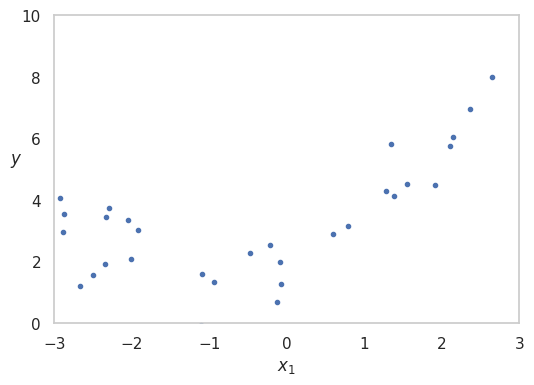

In [184]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.xlim([-3, 3])
plt.ylim([0, 10])
plt.grid()
plt.show()

- نلائم 6 نماذج تزيد في عدد معاملاتها لزيادة التفاصيل التي تستطيع تمثيلها
- ثم نقيس مجموع مطلق الأخطاء (MAE)
- سؤال: ما هو النموذج الأكثر ملاءمة للبيانات في نظرك؟

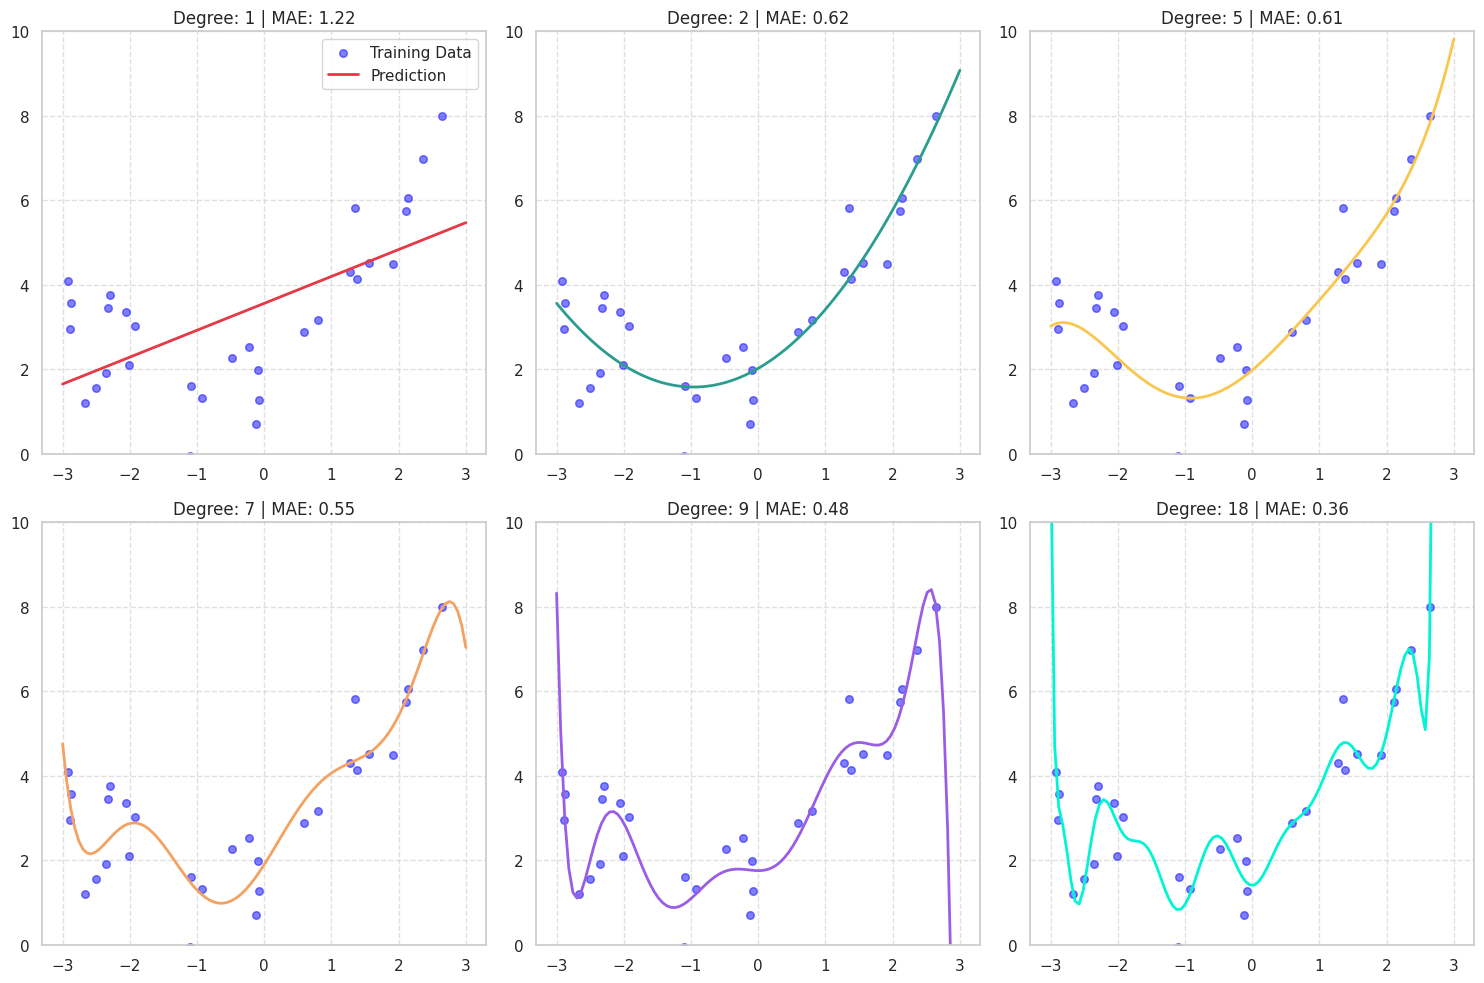

In [185]:
# | code-fold: true

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error


# 2. Setup for Predictions
X_new = np.linspace(-3, 3, 100).reshape(-1, 1)
df_preds = pd.DataFrame({"X_new": X_new.flatten()})

degrees = [1, 2, 5, 7, 9, 18] 
colors = ['#e63946', '#2a9d8f', '#f9c74f', '#f4a261', '#9b5de5', '#00f5d4']
scores = {} # Dictionary to store scores

# 3. Fit models and store predictions/scores
for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lin_reg", LinearRegression()),
    ])
    model.fit(X, y)
    
    # Calculate Score
    scores[degree] = mean_absolute_error(y, model.predict(X))
    
    col_name = f"Degree_{degree}"
    df_preds[col_name] = model.predict(X_new)

# 4. Plotting using Subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, degree in enumerate(degrees):
    ax = axes[i]
    col_name = f"Degree_{degree}"
    current_score = scores[degree]
    
    # Plot training data
    ax.scatter(X, y, color='blue', s=30, alpha=0.5, label="Training Data")
    
    # Plot model predictions
    ax.plot(df_preds["X_new"], df_preds[col_name], color=colors[i], linewidth=2, label="Prediction")
    
    # Updated title to include the score
    ax.set_title(f"Degree: {degree} | MAE: {current_score:.2f}")
    
    ax.set_ylim(0, 10) 
    ax.grid(True, linestyle='--', alpha=0.6)
    if i == 0: ax.legend()

plt.tight_layout()
plt.show()

## اختيار النموذج الأمثل

**التعميم** (Generalization): هو مدى ملاءمة النموذج لبيانات لم يعاينها أثناء التدريب. ويُقاسُ بمعيار الخطأ.

والنموذج الواحد يدخل عليه الخطأ من ناحيتين متعارضتين: **الانحياز** (Bias) و**التباين** (Variance).

فأما **الانحياز** (Bias): فهو متوسط خطأ التقدير على عينات التدريب. وسبب ذلك بساطة النموذج عن تمثيل التفاصيل في البيانات؛ إما لقلة المعاملات أو ضعف تركيبها. ويسمى نقص الملاءمة (Under-fitting).

وأما **التباين** (Variance):  ويعني تفاوُتَ الخطأ بمخالفة عينات التدريب. وسبب ذلك كثرة تفصيل النموذج (بكثرة المعاملات) أو قلة البيانات (ضعف البيانات عن التعبير عن النمط العام) أو كلاهما. ويسمى فرط الملاءمة (Over-fitting).


والنموذج الأمثل (Good-fit) وسطٌ بينهما:

- فالنموذَجُ: فيه من القدرة على التفصيل ما يناسب النمط الصغير، وفيه من القدرة على الإجمال ما يناسب النمط الكبير.
- والبيانات: مُبِينَة للنمطين: الكبير والصغير.

انظر: [Examples > Model Selection > Underfitting vs. Overfitting](https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html)

لنبين هذا الأمر، نعاين بيانات التدريب (مع الإرجاع) تسع مرات وننقطها في الشكل التالي:

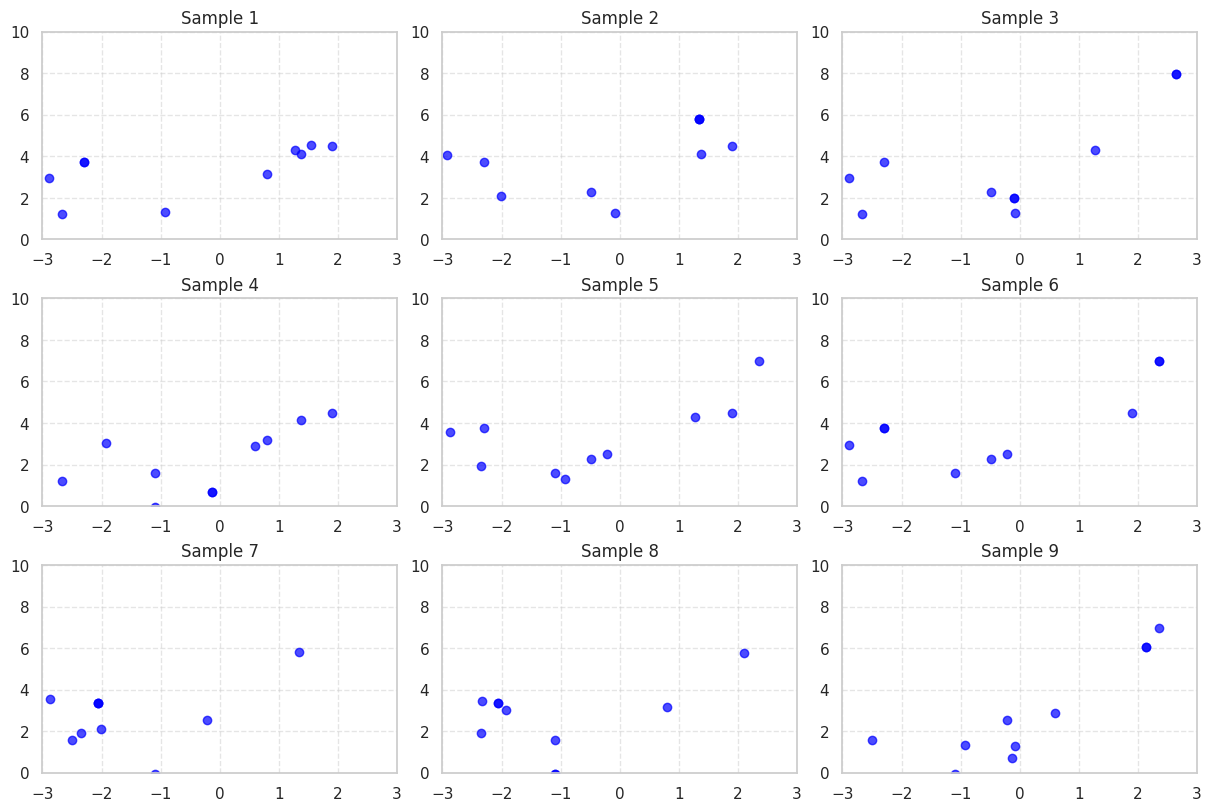

In [186]:
# | code-fold: true

import numpy as np
import matplotlib.pyplot as plt

# 2. Create a 3x3 grid of subplots
# Using constrained_layout to prevent overlap
fig, axes = plt.subplots(3, 3, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()  # Flatten to iterate easily

for i in range(9):
    # Perform sampling with replacement
    indices = np.random.choice(np.arange(m), size=10, replace=True)
    # This samples independently from the X and y columns
    x_sample = X[indices, 0]
    y_sample = y[indices, 0]

    # 3. Plot the sampled points
    axes[i].scatter(x_sample, y_sample, color='blue', alpha=0.7)
    
    # Set requested axis limits
    axes[i].set_xlim(-3, 3)
    axes[i].set_ylim(0, 10)
    
    axes[i].set_title(f'Sample {i+1}')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.show()

لاحظ حين نلائم ثلاث نماذج على عينات من بيانات التدريب كيف يؤثر ذلك على تغير معاملات النموذج، وبالتالي على شكلها (كالميل والانحدار والانعطاف):

- في أي هذه النماذج تجد التفاوُت أكبر؟
- وفي أيها تجد التفاوُتَ أقل ما يكون؟
- برأيك أي النماذج هو الأمثل بينها؟

In [196]:
# 1. Define the pipelines in a dictionary for easy iteration
models = {
    "m1": Pipeline([
        ('ploy', PolynomialFeatures(degree=1)),
        ('regressor', LinearRegression())
    ]),
    "m2": Pipeline([
        ('ploy', PolynomialFeatures(degree=4)),
        ('regressor', LinearRegression())
    ]),
    "m3": Pipeline([
        ('ploy', PolynomialFeatures(degree=9)),
        ('regressor', LinearRegression())
    ])
}

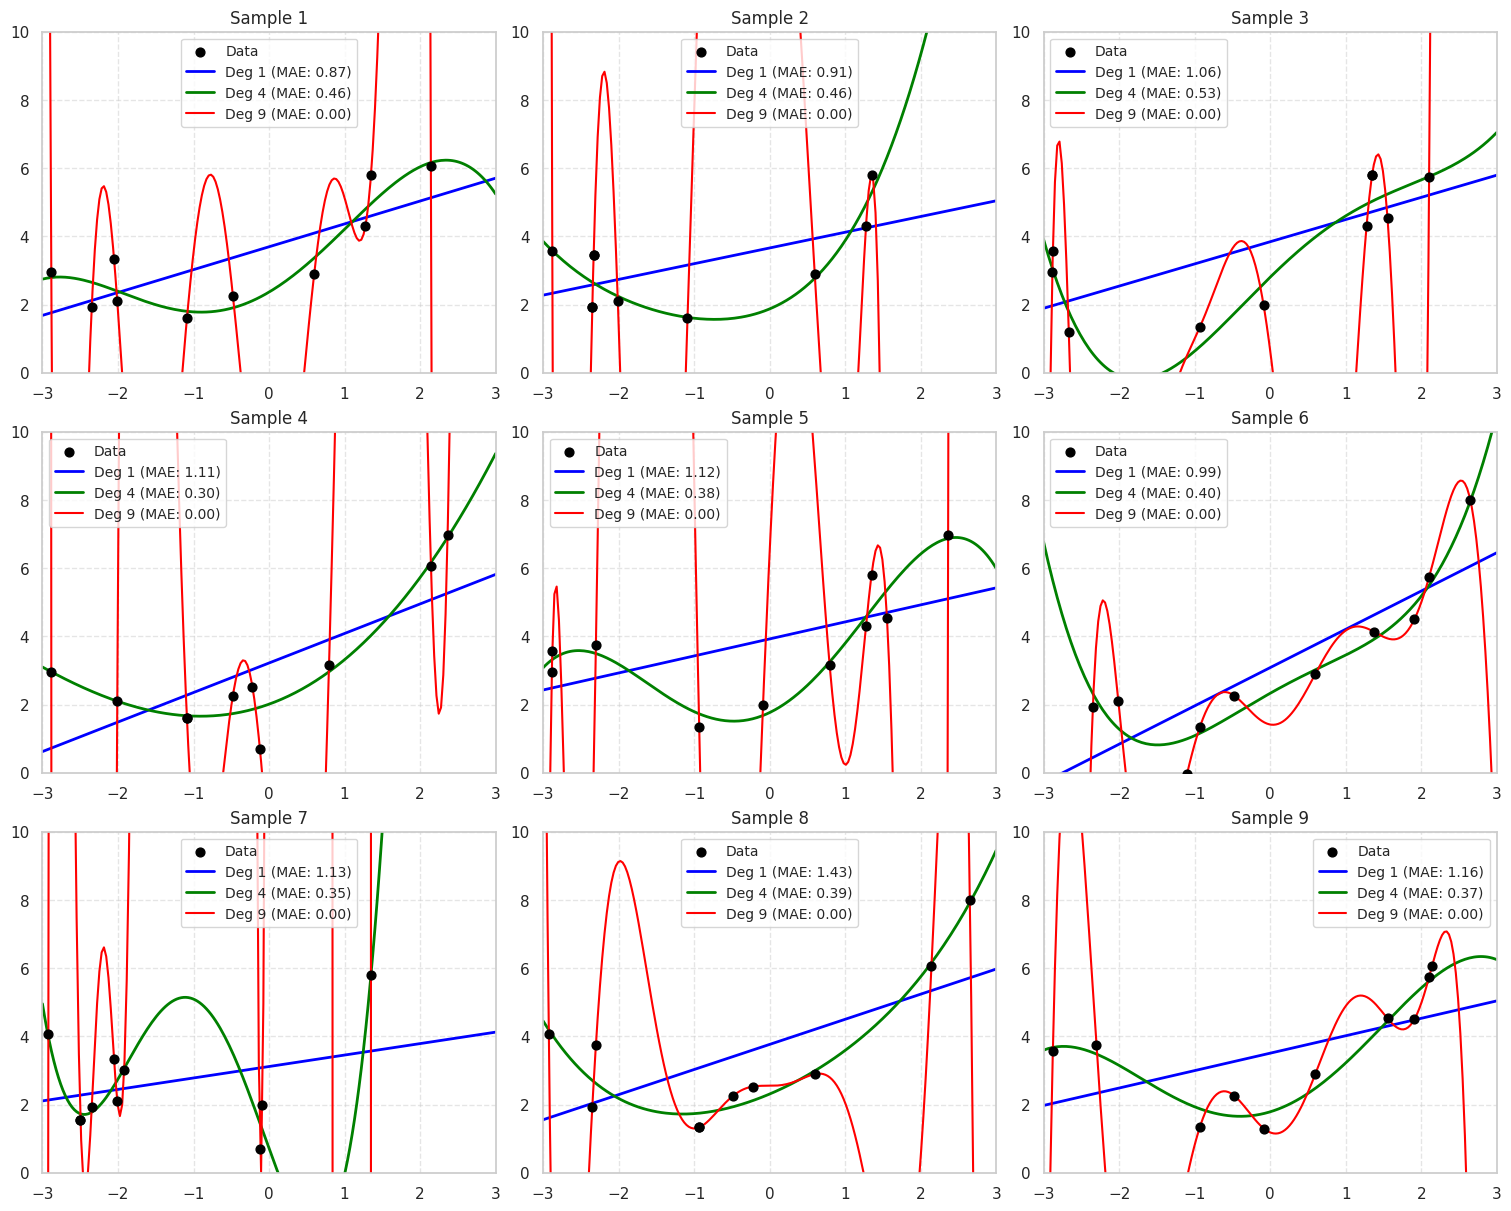

In [197]:
# | code-fold: true

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 2. Create subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)
axes = axes.flatten()

# Range for plotting curves
x_range = np.linspace(-3, 3, 200).reshape(-1, 1)

for i in range(9):
    # Sample 10 points with replacement
    indices = np.random.choice(np.arange(m), size=10, replace=True)
    x_sample = X[indices]
    y_sample = y[indices]

    # --- Pipeline 1: ---
    pipeline1 = models["m1"].fit(x_sample, y_sample)
    y_pred1 = pipeline1.predict(x_sample)
    mae1 = mean_absolute_error(y_sample, y_pred1)

    # --- Pipeline 2: ---
    pipeline2 = models["m2"].fit(x_sample, y_sample)
    y_pred3 = pipeline2.predict(x_sample)
    mae2 = mean_absolute_error(y_sample, y_pred3)

    # --- Pipeline 3: ---
    pipeline3 = models["m3"].fit(x_sample, y_sample)
    y_pred3 = pipeline3.predict(x_sample)
    mae3 = mean_absolute_error(y_sample, y_pred3)

    # --- Plotting ---
    axes[i].scatter(x_sample, y_sample, color='black', label='Data', s=40, zorder=3)
    
    # Plot curves
    y_range_pred1 = pipeline1.predict(x_range)
    y_range_pred2 = pipeline2.predict(x_range)
    y_range_pred3 = pipeline3.predict(x_range)
    
    axes[i].plot(x_range, y_range_pred1, color='blue', label=f'Deg 1 (MAE: {mae1:.2f})', linewidth=2)
    axes[i].plot(x_range, y_range_pred2, color='green', label=f'Deg 4 (MAE: {mae2:.2f})', linewidth=2)
    axes[i].plot(x_range, y_range_pred3, color='red', label=f'Deg 9 (MAE: {mae3:.2f})', linewidth=1.5)

    axes[i].set_xlim(-3, 3)
    axes[i].set_ylim(0, 10)
    axes[i].set_title(f'Sample {i+1}')
    axes[i].legend(fontsize='small')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.show()


## التحقق المتقاطع

يتم تقسيم البيانات إلى عينة تدريب وعينة اختبار، لقياس أداء النموذج على البيانات التي لم يرها بعد. وهذا التقسيم عشوائي:

```{mermaid}
flowchart TD
    A[Dataset] -- "random 80%" --> B[Training Set]
    A -- "random 20%" --> C[Testing Set]
```

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=0,
)
```

ثم يتم التدريب على القسم الأول:

```python
model.fit(X_train, ytrain)
```

والاختبار على القسم الثاني:

```python
score = model.score(X_test, y_test)
```

قد ينتج عن قياس أداء النموذج على عيِّنة الاختبار ملاءمة مثاليَّة؛ لمجرد أننا كنا محظوظين في اختيار عينتي التدريب والاختبار بحيث كانت عيِّنة التدريب مماثلة لعينة الاختبار.

أو قد نرى تبايُنًا كبيرًا أو تحيُّزًا مجحِفًا لسوء الحظ أيضًا.

ويتم تقليل نسبة الحظ بآلية **التحقق المتقاطع (cross-validation)**؛ حيث يتم تكرار عملية التقسيم العشوائي وقياس الأداء مرات ومرات، ثم يتم أخذ متوسط ذلك.

تظهر الآلية في القصاصة التالية حيث: **التقسيم مع الخلط العشوائي** (shuffle-split) مع التكرار 40 مرة.

```python
from sklearn.model_selection import cross_validate
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=40, test_size=0.3, random_state=0)
cv_results = cross_validate(
    regressor,
    data,
    target,
    cv=cv, # Cross-validation Strategy
    scoring="neg_mean_absolute_error"
)
```

![Figure: Shuffle Split](./assets/shufflesplit_diagram.png)

In [198]:
import pandas as pd
from sklearn.model_selection import cross_validate, ShuffleSplit

# 2. Define the Cross-Validation Strategy
cv = ShuffleSplit(n_splits=40, test_size=0.3, random_state=0)

# 3. Execute CV for each model and collect results
performance_data = []

for name, model in models.items():
    cv_results = cross_validate(
        model, X, y, cv=cv,
        scoring="neg_mean_absolute_error",
        return_train_score=True
    )
    
    # We store two entries per model: one for Train and one for Test.
    # This "Long-Form" structure is what plotting engines require for grouped bars.
    for train_score, test_score in zip(cv_results["train_score"], cv_results["test_score"]):
        performance_data.append({
            "Model": name,
            "Score": train_score,
            "Type": "Train"
        })
        performance_data.append({
            "Model": name,
            "Score": test_score,
            "Type": "Test"
        })

In [199]:
df_results = pd.DataFrame(performance_data)
df_results

,Model,Score,Type
0,m1,-1.387075,Train
1,m1,-0.800743,Test
2,m1,-1.095499,Train
3,m1,-1.617094,Test
4,m1,-1.255291,Train
...,...,...,...
235,m3,-0.647800,Test
236,m3,-0.478345,Train
237,m3,-0.651546,Test
238,m3,-0.447889,Train


In [201]:
df_results.groupby(by=['Model', 'Type']).agg(['mean'])

Score
                 mean
Model Type           
m1    Test  -1.309189
      Train -1.210961
m2    Test  -0.861972
      Train -0.621575
m3    Test  -2.143465
      Train -0.414986

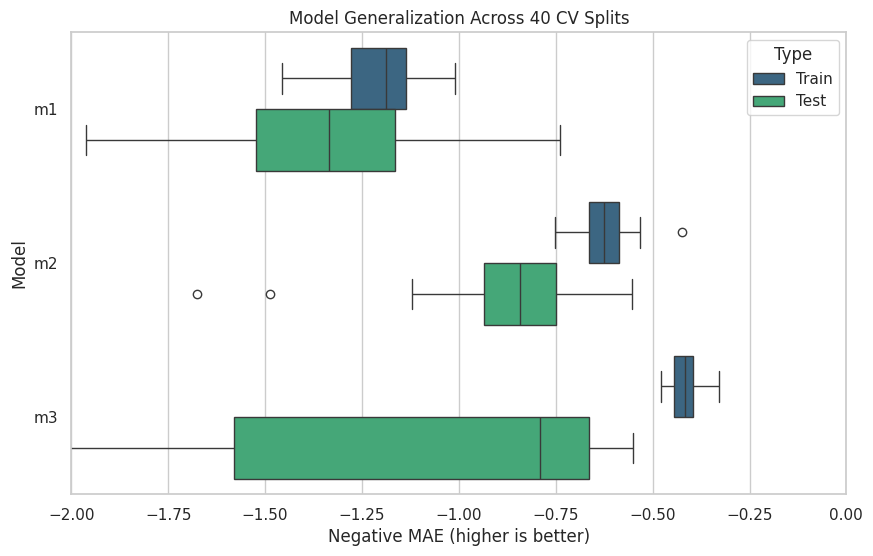

In [202]:
import seaborn as sns

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# ci="sd" draws the standard deviation. Default is a 95% confidence interval.
ax = sns.boxplot(
    data=df_results, 
    y="Model", 
    x="Score",
    orient='h', 
    hue="Type", 
    palette="viridis",
)

plt.title("Model Generalization Across 40 CV Splits")
plt.xlabel("Negative MAE (higher is better)")
plt.ylabel("Model")
plt.xlim(-2, 0)
plt.show()